# Core CPI Prediction Backtest: Ideal vs FSBI vs No-FSBI

This notebook tests whether model-based forecasts of **Core CPI YoY** can be translated into event-driven trading signals.

The benchmark compares three signal definitions on the same Core CPI release dates:

- **Ideal**: actual first-release Core CPI YoY minus market consensus. This is the perfect-information benchmark.
- **With FSBI**: FSBI model prediction minus market consensus. This represents the forecast-driven strategy using FSBI information.
- **Without FSBI**: non-FSBI model prediction minus market consensus. This is the forecast-driven strategy without FSBI inputs.

The trading assumption is intentionally idealized: transaction costs, bid-ask spreads, slippage, financing costs, and shorting costs are set to zero. The goal is not to estimate live implementation costs, but to isolate whether the economic signal has directional value.

The notebook does not write result CSV files. It displays tables and charts directly in Jupyter.

## 1. Setup

This section imports the Python libraries and defines the input files.

Inputs used by the notebook:

- `market_core_inflation_consensus.csv`: market consensus data for Core CPI YoY.
- `fsbi_predictions_for_lee_combined_v3.csv`: model predictions with FSBI, model predictions without FSBI, actual first-release values, and release dates.

The active macro indicator is **Core CPI YoY**. Core PCE rows may exist in the source prediction file, but this notebook filters to Core CPI because the trading strategy and consensus file are aligned around Core CPI releases.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    plt.switch_backend('Agg')

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 140)

In [2]:
market_consensus_csv = Path('market_core_inflation_consensus.csv')
fsbi_predictions_csv = Path('fsbi_predictions_for_lee_combined_v3.csv')

indicator_mode = 'core_cpi'
indicator_label = 'Core CPI YOY%'
cost = 0.0
vixy_threshold = 0.1

## 2. Build the Three Signals

This section creates the trading signal table.

Economic idea:

Markets usually react to the **surprise component** of a macro release, not the level alone. For inflation data, the surprise is measured relative to what the market expected before the announcement.

Signal definitions:

- `ideal_surprise = actual_first_release - market_consensus_yoy`
- `fsbi_surprise = pred_with_fsbi - market_consensus_yoy`
- `no_fsbi_surprise = pred_without_fsbi - market_consensus_yoy`

The model-based strategies are therefore asking a simple question: before the official release, did the model predict an inflation print above or below consensus?

Code logic:

1. Filter the prediction file to `Core CPI YOY%`.
2. Convert the reference period and release dates into proper datetime values.
3. Merge the model predictions with market consensus using the same reference period.
4. Drop rows where market consensus is unavailable.
5. Create the three surprise columns used later in the backtest.

The notebook uses `Actual Release Date` from the prediction file as the tradable event date. This keeps the backtest aligned with the prediction dataset's event timing.

In [3]:
def load_prediction_signal_table(prediction_path, consensus_path):
    pred = pd.read_csv(prediction_path)
    consensus = pd.read_csv(consensus_path)

    pred = pred[pred['Economic Indicator'].str.strip().str.lower().eq(indicator_label.lower())].copy()
    pred['period'] = pd.to_datetime(pred['Reference Period'], format='%Y-%m')
    pred['prediction_date'] = pd.to_datetime(pred['Model Prediction Date'], format='%Y-%m')
    pred['release_date'] = pd.to_datetime(pred['Actual Release Date']).dt.tz_localize(None)

    pred = pred.rename(columns={
        'Predicted Value (with FSBI)': 'pred_with_fsbi',
        'Predicted Value (w/o FSBI)': 'pred_without_fsbi',
        'Actual First-Release Value': 'actual_first_release',
        'CV Fold': 'cv_fold',
    })

    consensus = consensus[consensus['indicator'].eq(indicator_mode)].copy()
    consensus['period'] = pd.to_datetime(consensus['period']).dt.tz_localize(None)
    consensus = consensus.rename(columns={
        'release_date': 'consensus_file_release_date',
        'actual_yoy': 'market_actual_yoy',
        'consensus_yoy': 'market_consensus_yoy',
        'market_source': 'consensus_source',
    })

    merged = pred.merge(
        consensus[['period', 'consensus_file_release_date', 'market_actual_yoy', 'market_consensus_yoy', 'consensus_source']],
        on='period',
        how='left',
    )

    excluded = merged[merged['market_consensus_yoy'].isna()].copy()
    signal = merged.dropna(subset=['market_consensus_yoy']).copy()
    signal = signal.sort_values('release_date').reset_index(drop=True)

    signal['ideal_surprise'] = signal['actual_first_release'] - signal['market_consensus_yoy']
    signal['fsbi_surprise'] = signal['pred_with_fsbi'] - signal['market_consensus_yoy']
    signal['no_fsbi_surprise'] = signal['pred_without_fsbi'] - signal['market_consensus_yoy']

    cols = [
        'period', 'prediction_date', 'release_date', 'market_consensus_yoy',
        'actual_first_release', 'pred_with_fsbi', 'pred_without_fsbi',
        'ideal_surprise', 'fsbi_surprise', 'no_fsbi_surprise',
        'cv_fold', 'consensus_source', 'consensus_file_release_date', 'market_actual_yoy',
    ]
    return signal[cols], excluded

signal_table, excluded_predictions = load_prediction_signal_table(fsbi_predictions_csv, market_consensus_csv)

print('Prediction rows used:', len(signal_table))
print('Date range:', signal_table['release_date'].min().date(), 'to', signal_table['release_date'].max().date())
print('Trading cost:', cost)

if not excluded_predictions.empty:
    print('Excluded rows without market consensus:')
    display(excluded_predictions[['Economic Indicator', 'Reference Period', 'Actual Release Date', 'actual_first_release']])

display(signal_table.tail(10))

Prediction rows used: 35
Date range: 2023-05-10 to 2026-05-12
Trading cost: 0.0
Excluded rows without market consensus:


,Economic Indicator,Reference Period,Actual Release Date,actual_first_release
30,Core CPI YOY%,2025-10,2025-12-18,2.599


,period,prediction_date,release_date,market_consensus_yoy,actual_first_release,pred_with_fsbi,pred_without_fsbi,ideal_surprise,fsbi_surprise,no_fsbi_surprise,cv_fold,consensus_source,consensus_file_release_date,market_actual_yoy
25,2025-05-01,2025-04-01,2025-06-11,2.9,2.9109,2.7871,2.8434,0.0109,-0.1129,-0.0566,3,Nasdaq economic calendar Core CPI YoY,2025-06-12,2.8
26,2025-06-01,2025-05-01,2025-07-15,3.0,3.0545,2.8401,2.8307,0.0545,-0.1599,-0.1693,3,Nasdaq economic calendar Core CPI YoY,2025-07-16,2.9
27,2025-07-01,2025-06-01,2025-08-12,3.0,3.1118,2.8855,2.9021,0.1118,-0.1145,-0.0979,3,Nasdaq economic calendar Core CPI YoY,2025-08-13,3.1
28,2025-08-01,2025-07-01,2025-09-11,3.1,3.0200,2.9358,2.9879,-0.0800,-0.1642,-0.1121,3,Nasdaq economic calendar Core CPI YoY,2025-09-12,3.1
29,2025-09-01,2025-08-01,2025-10-24,3.1,2.7001,2.9903,3.0025,-0.3999,-0.1097,-0.0975,3,News cross-check delayed Core CPI YoY,2025-10-24,3.0
30,2025-12-01,2025-11-01,2026-01-13,2.7,2.5120,2.9559,2.6373,-0.1880,0.2559,-0.0627,3,Nasdaq economic calendar Core CPI YoY,2026-01-14,2.6
31,2026-01-01,2025-12-01,2026-02-13,2.5,2.4725,3.0899,2.6460,-0.0275,0.5899,0.1460,3,Nasdaq economic calendar Core CPI YoY,2026-02-13,2.5
32,2026-02-01,2026-01-01,2026-03-11,2.5,2.6022,3.0868,2.5642,0.1022,0.5868,0.0642,3,Nasdaq economic calendar Core CPI YoY,2026-03-12,2.5
33,2026-03-01,2026-02-01,2026-04-10,2.7,2.7433,3.0050,2.5227,0.0433,0.3050,-0.1773,3,Nasdaq economic calendar Core CPI YoY,2026-04-10,2.6
34,2026-04-01,2026-03-01,2026-05-12,2.7,2.8229,3.0527,2.6010,0.1229,0.3527,-0.0990,3,Nasdaq economic calendar Core CPI YoY,2026-05-13,2.8


## 3. Backtest Helpers

This section defines reusable functions for downloading ETF prices, converting macro surprises into trading directions, running event-window backtests, summarizing performance, and plotting results.

Trading window:

- **Entry**: close of the trading day immediately before the Core CPI release.
- **Exit**: close of the Core CPI release day.
- **Costs**: zero.

Why this event window is used:

Core CPI is released before the U.S. equity market open. Using the previous close to release-day close approximates a clean event-day response window using daily ETF data.

Core signal convention:

- A hotter-than-consensus inflation surprise is usually negative for duration-sensitive bonds and growth equities.
- A cooler-than-consensus inflation surprise is usually supportive for duration and growth assets.

The helper functions keep the signal logic consistent across all strategies, so each section below changes only the asset exposure, not the backtest mechanics.

In [4]:
MODEL_SPECS = {
    'Ideal': 'ideal_surprise',
    'With FSBI': 'fsbi_surprise',
    'Without FSBI': 'no_fsbi_surprise',
}

ALL_TICKERS = ['TLT', 'SHY', 'IEF', 'QQQ', 'SPY', 'IWM', 'VTV', 'XLK', 'XLF', 'UUP', 'VIXY', 'DBC', 'GLD']


def download_close(tickers, start, end):
    px = yf.download(
        tickers,
        start=pd.to_datetime(start) - pd.Timedelta(days=10),
        end=pd.to_datetime(end) + pd.Timedelta(days=2),
        auto_adjust=True,
        progress=False,
    )
    close = px['Close'] if isinstance(px.columns, pd.MultiIndex) else px
    if isinstance(close, pd.Series):
        close = close.to_frame(tickers[0] if isinstance(tickers, list) else tickers)
    close.index = pd.to_datetime(close.index).tz_localize(None)
    return close.dropna(how='all')


def event_signal(surprise):
    if surprise > 0:
        return -1
    if surprise < 0:
        return 1
    return 0


def dollar_signal(surprise):
    if surprise > 0:
        return 1
    if surprise < 0:
        return -1
    return 0


def commodity_signal(surprise):
    if surprise > 0:
        return 1
    if surprise < 0:
        return -1
    return 0


def vixy_signal(surprise):
    return 1 if abs(surprise) >= vixy_threshold else 0


def pct(x):
    return x * 100


def display_percent_table(df, pct_cols=None, decimals=2):
    out = df.copy()
    for col in pct_cols or []:
        if col in out.columns:
            out[col] = out[col].map(lambda x: '' if pd.isna(x) else f'{x:.{decimals}f}%')
    display(out)


def run_directional_model(signal_table, prices, ticker, strategy, model_name, surprise_col, signal_fn=event_signal):
    rows = []
    valid_prices = prices[[ticker]].dropna()
    dates = valid_prices.index

    for _, r in signal_table.iterrows():
        release_date = pd.Timestamp(r.release_date).normalize()
        if release_date not in dates:
            continue
        exit_i = dates.get_loc(release_date)
        entry_i = exit_i - 1
        if entry_i < 0:
            continue

        signal = signal_fn(r[surprise_col])
        entry_date, exit_date = dates[entry_i], dates[exit_i]
        asset_ret = valid_prices.loc[exit_date, ticker] / valid_prices.loc[entry_date, ticker] - 1
        ret = 0 if signal == 0 else signal * asset_ret - cost

        rows.append({
            **r.to_dict(),
            'strategy': strategy,
            'model': model_name,
            'surprise_used': r[surprise_col],
            'ticker': ticker,
            'signal': signal,
            'entry_date': entry_date,
            'exit_date': exit_date,
            'asset_return': asset_ret,
            'return': ret,
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        out['cum_return'] = (1 + out['return']).cumprod() - 1
    return out


def run_pair_model(signal_table, prices, long_leg, short_leg, strategy, model_name, surprise_col, signal_fn=event_signal):
    rows = []
    valid_prices = prices[[long_leg, short_leg]].dropna()
    dates = valid_prices.index

    for _, r in signal_table.iterrows():
        release_date = pd.Timestamp(r.release_date).normalize()
        if release_date not in dates:
            continue
        exit_i = dates.get_loc(release_date)
        entry_i = exit_i - 1
        if entry_i < 0:
            continue

        signal = signal_fn(r[surprise_col])
        entry_date, exit_date = dates[entry_i], dates[exit_i]
        long_ret = valid_prices.loc[exit_date, long_leg] / valid_prices.loc[entry_date, long_leg] - 1
        short_ret = valid_prices.loc[exit_date, short_leg] / valid_prices.loc[entry_date, short_leg] - 1
        gross = 0.5 * signal * (long_ret - short_ret)
        ret = 0 if signal == 0 else gross - 2 * cost

        rows.append({
            **r.to_dict(),
            'strategy': strategy,
            'model': model_name,
            'surprise_used': r[surprise_col],
            'pair': f'{long_leg}/{short_leg}',
            'signal': signal,
            'entry_date': entry_date,
            'exit_date': exit_date,
            f'{long_leg.lower()}_return': long_ret,
            f'{short_leg.lower()}_return': short_ret,
            'return': ret,
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        out['cum_return'] = (1 + out['return']).cumprod() - 1
    return out


def run_strategy_for_all_models(strategy_def, prices):
    outputs = []
    for model_name, surprise_col in MODEL_SPECS.items():
        if strategy_def['kind'] == 'directional':
            bt = run_directional_model(
                signal_table, prices, strategy_def['ticker'], strategy_def['name'],
                model_name, surprise_col, strategy_def.get('signal_fn', event_signal),
            )
        else:
            bt = run_pair_model(
                signal_table, prices, strategy_def['long_leg'], strategy_def['short_leg'], strategy_def['name'],
                model_name, surprise_col, strategy_def.get('signal_fn', event_signal),
            )
        outputs.append(bt)
    return pd.concat(outputs, ignore_index=True)


def summarize_backtest(bt):
    rows = []
    for (strategy, model), g in bt.groupby(['strategy', 'model'], sort=False):
        trades = g[g['signal'] != 0]
        eq = (1 + g['return']).cumprod()
        dd = eq / eq.cummax() - 1
        rows.append({
            'Strategy': strategy,
            'Model': model,
            'Events': len(g),
            'Trades': len(trades),
            'Total return (%)': pct(eq.iloc[-1] - 1) if len(g) else np.nan,
            'Avg trade (%)': pct(trades['return'].mean()) if len(trades) else np.nan,
            'Win rate (%)': pct((trades['return'] > 0).mean()) if len(trades) else np.nan,
            'Sharpe': trades['return'].mean() / trades['return'].std() * np.sqrt(12) if len(trades) > 1 and trades['return'].std() != 0 else np.nan,
            'Max DD (%)': pct(dd.min()) if len(g) else np.nan,
        })
    return pd.DataFrame(rows)


MODEL_STYLE = {
    'Ideal': {
        'color': '#0f766e',
        'linestyle': '-',
        'linewidth': 2.6,
        'marker': None,
        'alpha': 0.96,
        'zorder': 4,
    },
    'With FSBI': {
        'color': '#6366f1',
        'linestyle': (0, (5, 3)),
        'linewidth': 2.35,
        'marker': 'o',
        'markersize': 3.2,
        'alpha': 0.86,
        'zorder': 3,
    },
    'Without FSBI': {
        'color': '#e11d48',
        'linestyle': (0, (1.4, 2.4)),
        'linewidth': 2.5,
        'marker': 'D',
        'markersize': 3.0,
        'alpha': 0.82,
        'zorder': 2,
    },
}


def spread_label_positions(endpoints, y_range):
    if not endpoints:
        return []
    min_gap = max(0.75, y_range * 0.085)
    ordered = sorted(endpoints, key=lambda item: item['y'])

    adjusted = []
    last_y = None
    for item in ordered:
        label_y = item['y'] if last_y is None else max(item['y'], last_y + min_gap)
        adjusted.append({**item, 'label_y': label_y})
        last_y = label_y

    original_min = min(item['y'] for item in endpoints)
    original_max = max(item['y'] for item in endpoints)
    max_allowed = original_max + max(min_gap, y_range * 0.18)
    overflow = adjusted[-1]['label_y'] - max_allowed
    if overflow > 0:
        adjusted = [{**item, 'label_y': item['label_y'] - overflow} for item in adjusted]

    return adjusted


def plot_strategy_comparison(bt, title):
    fig, ax = plt.subplots(figsize=(11.2, 4.9))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('#ffffff')

    endpoints = []
    all_y_values = []
    all_x_values = []

    for model in MODEL_SPECS.keys():
        g = bt[bt['model'].eq(model)].sort_values('exit_date')
        if g.empty:
            continue
        curve = g.set_index('exit_date')['cum_return'] * 100
        style = MODEL_STYLE[model].copy()
        marker = style.pop('marker')
        markersize = style.pop('markersize', None)
        markevery = max(1, len(curve) // 7)

        ax.plot(
            curve.index,
            curve.values,
            drawstyle='steps-post',
            label=f'{model}  {curve.iloc[-1]:.2f}%',
            marker=marker,
            markersize=markersize if marker else None,
            markevery=markevery if marker else None,
            markerfacecolor='white' if marker else None,
            markeredgewidth=1.1 if marker else None,
            markeredgecolor=style['color'] if marker else None,
            solid_capstyle='round',
            dash_capstyle='round',
            **style,
        )

        endpoints.append({
            'model': model,
            'x': curve.index[-1],
            'y': float(curve.iloc[-1]),
            'color': style['color'],
        })
        all_y_values.extend(curve.values.tolist())
        all_x_values.extend(curve.index.tolist())

    y_min = min(all_y_values) if all_y_values else 0
    y_max = max(all_y_values) if all_y_values else 1
    y_range = max(y_max - y_min, 1.0)
    adjusted_endpoints = spread_label_positions(endpoints, y_range)

    first_x = min(all_x_values) if all_x_values else pd.Timestamp.today()
    last_x = max(all_x_values) if all_x_values else pd.Timestamp.today()
    x_span_days = max((last_x - first_x).days, 1)
    label_x = last_x + pd.Timedelta(days=max(14, int(x_span_days * 0.045)))
    right_x = last_x + pd.Timedelta(days=max(55, int(x_span_days * 0.15)))

    for item in adjusted_endpoints:
        ax.plot(
            [item['x'], label_x],
            [item['y'], item['label_y']],
            color=item['color'],
            linewidth=0.85,
            alpha=0.45,
            solid_capstyle='round',
            zorder=1,
        )
        ax.text(
            label_x,
            item['label_y'],
            f"{item['y']:.1f}%",
            va='center',
            ha='left',
            fontsize=9,
            color=item['color'],
            fontweight='semibold',
            bbox=dict(boxstyle='round,pad=0.22', facecolor='white', edgecolor='#e5e7eb', linewidth=0.7, alpha=0.92),
            zorder=6,
        )

    label_y_values = [item['label_y'] for item in adjusted_endpoints]
    display_y_min = min([y_min] + label_y_values)
    display_y_max = max([y_max] + label_y_values)
    pad = max((display_y_max - display_y_min) * 0.14, 1.0)

    ax.axhline(0, color='#64748b', linewidth=0.9, alpha=0.85)
    ax.set_title(title, fontsize=13, fontweight='semibold', color='#111827', pad=12)
    ax.set_ylabel('Cumulative Return (%)', color='#374151')
    ax.set_xlabel('Release date', color='#374151')
    ax.tick_params(axis='both', colors='#4b5563', labelsize=9)
    ax.grid(True, axis='y', color='#e5e7eb', linewidth=0.9, alpha=0.95)
    ax.grid(False, axis='x')
    ax.set_xlim(first_x, right_x)
    ax.set_ylim(display_y_min - pad, display_y_max + pad)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#d1d5db')
    ax.spines['bottom'].set_color('#d1d5db')

    legend = ax.legend(
        loc='best',
        frameon=True,
        fancybox=True,
        framealpha=0.96,
        facecolor='white',
        edgecolor='#e5e7eb',
        fontsize=9,
        handlelength=2.8,
        borderpad=0.8,
        labelspacing=0.55,
    )
    for text in legend.get_texts():
        text.set_color('#374151')

    plt.tight_layout()
    plt.show()
    return ax


def show_strategy_comparison(bt, title):
    summary = summarize_backtest(bt)
    display_percent_table(summary, ['Total return (%)', 'Avg trade (%)', 'Win rate (%)', 'Max DD (%)'])
    plot_strategy_comparison(bt, title)

In [5]:
start = signal_table['release_date'].min().strftime('%Y-%m-%d')
end = signal_table['release_date'].max().strftime('%Y-%m-%d')
prices = download_close(ALL_TICKERS, start, end)
print('Price date range:', prices.index.min().date(), 'to', prices.index.max().date())
print('Tickers loaded:', ', '.join(prices.columns.tolist()))

Price date range: 2023-05-01 to 2026-05-13
Tickers loaded: DBC, GLD, IEF, IWM, QQQ, SHY, SPY, TLT, UUP, VIXY, VTV, XLF, XLK


## 4. Strategy-by-Strategy Results

Each strategy below is run three times: `Ideal`, `With FSBI`, and `Without FSBI`.

For each strategy, the notebook reports a performance table and plots cumulative return paths for the three signal versions.

The purpose is to separate two questions:

1. Does the **perfect surprise** have tradable value for the asset?
2. Does the **model-predicted surprise** capture enough of that value before the release?

All charts show cumulative return in percent.

### 1. TLT Directional

Economic reasoning:

`TLT` is a long-duration Treasury ETF. Long-duration bonds are highly sensitive to inflation and expected policy rates. A hotter Core CPI surprise can push yields higher and hurt long-duration bonds, while a cooler surprise can support them.

Trading rule:

- Positive surprise: short TLT.
- Negative surprise: long TLT.
- Zero surprise: no position.

Code behavior:

The code runs the same TLT directional rule for the `Ideal`, `With FSBI`, and `Without FSBI` signals, then plots the three cumulative return paths.

,Strategy,Model,Events,Trades,Total return (%),Avg trade (%),Win rate (%),Sharpe,Max DD (%)
0,TLT directional,Ideal,35,35,3.80%,0.11%,62.86%,0.327635,-4.33%
1,TLT directional,With FSBI,35,35,6.27%,0.18%,57.14%,0.525044,-4.88%
2,TLT directional,Without FSBI,35,35,6.72%,0.19%,57.14%,0.560460,-3.66%


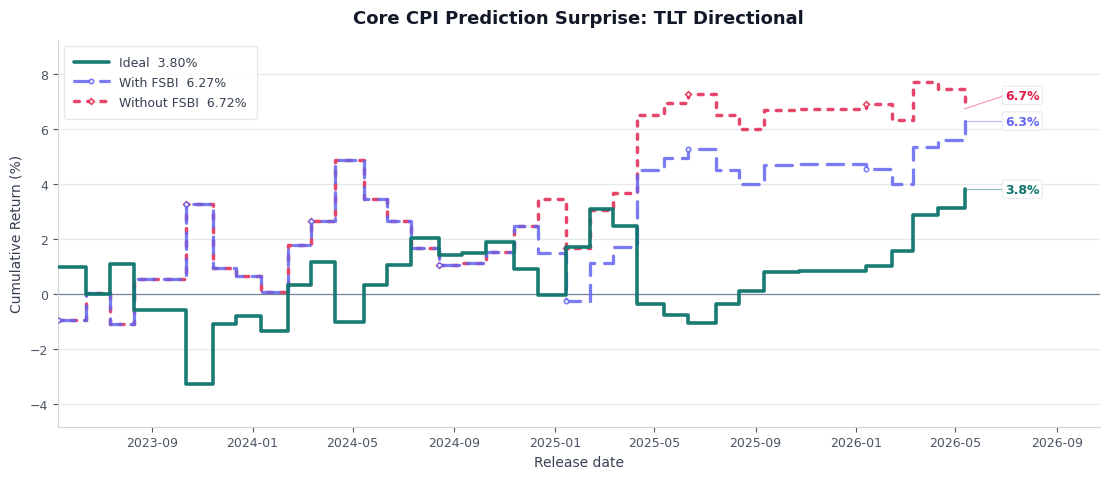

In [6]:
bt_tlt_directional = run_strategy_for_all_models({'name': 'TLT directional', 'kind': 'directional', 'ticker': 'TLT', 'title': 'Core CPI Prediction Surprise: TLT Directional'}, prices)
show_strategy_comparison(bt_tlt_directional, 'Core CPI Prediction Surprise: TLT Directional')

### 2. TLT / SHY Spread

Economic reasoning:

This is a Treasury duration spread. `TLT` has much longer duration than `SHY`, so the pair is designed to isolate the duration response to inflation surprises while reducing broad Treasury market exposure.

Trading rule:

- Cooler-than-consensus signal: long TLT and short SHY.
- Hotter-than-consensus signal: short TLT and long SHY.

Code behavior:

The pair strategy uses a 50/50 long-short return calculation. It compares whether the inflation signal works better as a relative duration trade than as a simple TLT directional trade.

,Strategy,Model,Events,Trades,Total return (%),Avg trade (%),Win rate (%),Sharpe,Max DD (%)
0,TLT/SHY spread,Ideal,35,35,1.08%,0.03%,57.14%,0.204445,-2.14%
1,TLT/SHY spread,With FSBI,35,35,3.43%,0.10%,51.43%,0.633881,-2.00%
2,TLT/SHY spread,Without FSBI,35,35,3.71%,0.11%,51.43%,0.685579,-1.58%


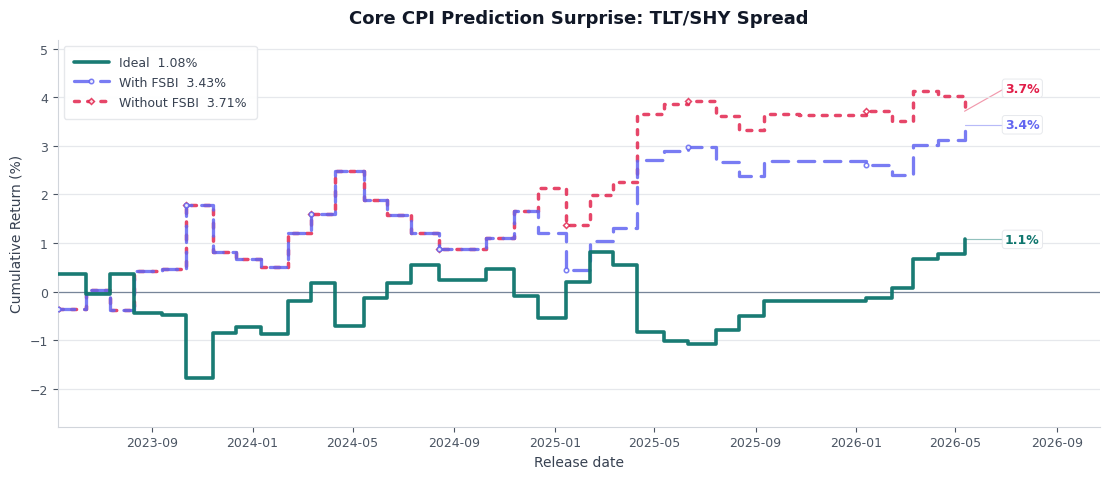

In [7]:
bt_tlt_shy_spread = run_strategy_for_all_models({'name': 'TLT/SHY spread', 'kind': 'pair', 'long_leg': 'TLT', 'short_leg': 'SHY', 'title': 'Core CPI Prediction Surprise: TLT/SHY Spread'}, prices)
show_strategy_comparison(bt_tlt_shy_spread, 'Core CPI Prediction Surprise: TLT/SHY Spread')

### 3. TLT / IEF Spread

Economic reasoning:

This is another Treasury duration spread, but `IEF` has intermediate duration and is closer to TLT than SHY. The trade tests whether the inflation surprise is mainly about long-duration exposure rather than the entire yield curve.

Trading rule:

- Cooler signal: long TLT and short IEF.
- Hotter signal: short TLT and long IEF.

Code behavior:

The strategy applies the same signal direction as TLT, but expresses it as long-duration versus intermediate-duration Treasuries.

,Strategy,Model,Events,Trades,Total return (%),Avg trade (%),Win rate (%),Sharpe,Max DD (%)
0,TLT/IEF spread,Ideal,35,35,-0.42%,-0.01%,62.86%,-0.118273,-1.91%
1,TLT/IEF spread,With FSBI,35,35,3.06%,0.09%,51.43%,0.932753,-0.84%
2,TLT/IEF spread,Without FSBI,35,35,3.36%,0.09%,51.43%,1.031067,-0.81%


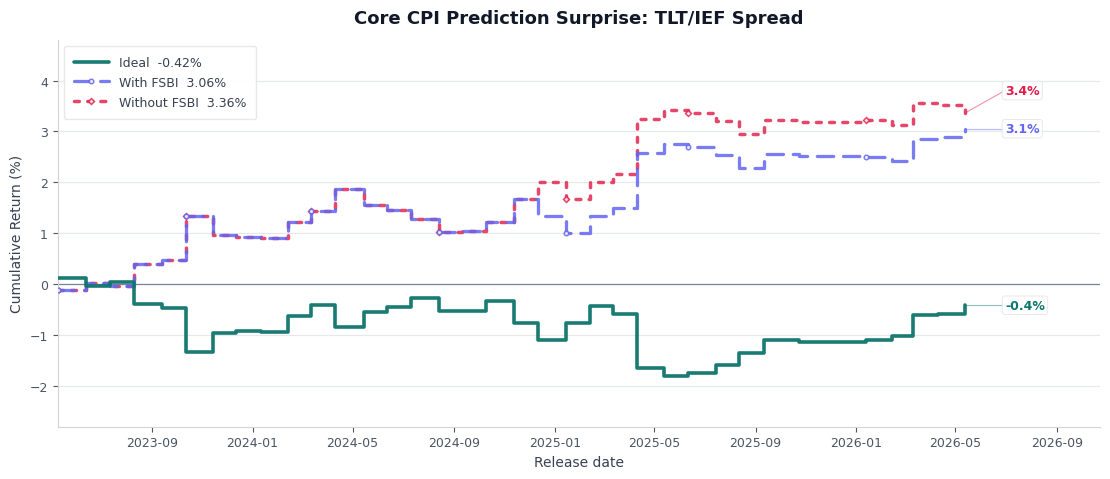

In [8]:
bt_tlt_ief_spread = run_strategy_for_all_models({'name': 'TLT/IEF spread', 'kind': 'pair', 'long_leg': 'TLT', 'short_leg': 'IEF', 'title': 'Core CPI Prediction Surprise: TLT/IEF Spread'}, prices)
show_strategy_comparison(bt_tlt_ief_spread, 'Core CPI Prediction Surprise: TLT/IEF Spread')

### 4. QQQ Directional

Economic reasoning:

`QQQ` is a growth-heavy equity ETF. Growth stocks tend to be sensitive to discount rates. A hotter inflation surprise can raise expected rates and pressure growth equities, while a cooler surprise can support them.

Trading rule:

- Positive inflation surprise: short QQQ.
- Negative inflation surprise: long QQQ.

Code behavior:

The code applies the Core CPI surprise direction directly to QQQ and compares whether model-based predictions can anticipate the equity market response.

,Strategy,Model,Events,Trades,Total return (%),Avg trade (%),Win rate (%),Sharpe,Max DD (%)
0,QQQ directional,Ideal,35,35,7.61%,0.22%,60.00%,0.567410,-4.36%
1,QQQ directional,With FSBI,35,35,-4.02%,-0.11%,42.86%,-0.278566,-8.54%
2,QQQ directional,Without FSBI,35,35,-8.96%,-0.26%,37.14%,-0.677585,-11.76%


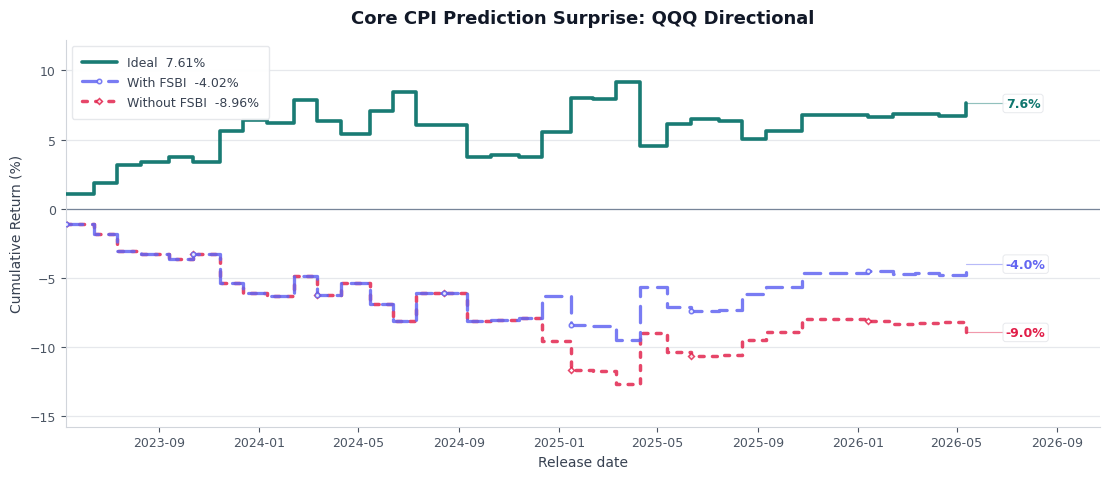

In [9]:
bt_qqq_directional = run_strategy_for_all_models({'name': 'QQQ directional', 'kind': 'directional', 'ticker': 'QQQ', 'title': 'Core CPI Prediction Surprise: QQQ Directional'}, prices)
show_strategy_comparison(bt_qqq_directional, 'Core CPI Prediction Surprise: QQQ Directional')

### 5. QQQ / SPY Pair

Economic reasoning:

This pair tests whether inflation surprises affect growth-heavy equities differently from the broad equity market. `QQQ` is more rate-sensitive than `SPY`, so the relative trade focuses on growth versus broad beta.

Trading rule:

- Cooler signal: long QQQ and short SPY.
- Hotter signal: short QQQ and long SPY.

Code behavior:

The pair return is computed as a 50/50 long-short spread. This helps distinguish a growth-specific effect from a general equity-market move.

,Strategy,Model,Events,Trades,Total return (%),Avg trade (%),Win rate (%),Sharpe,Max DD (%)
0,QQQ/SPY pair,Ideal,35,35,1.56%,0.04%,65.71%,0.637235,-1.21%
1,QQQ/SPY pair,With FSBI,35,35,-1.89%,-0.05%,25.71%,-0.782772,-2.02%
2,QQQ/SPY pair,Without FSBI,35,35,-3.30%,-0.10%,25.71%,-1.465425,-3.01%


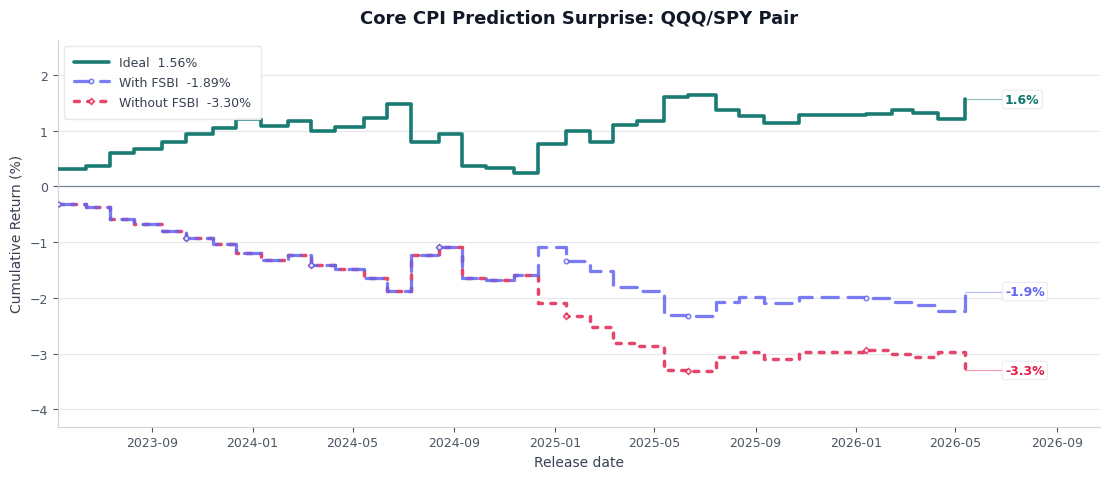

In [10]:
bt_qqq_spy_pair = run_strategy_for_all_models({'name': 'QQQ/SPY pair', 'kind': 'pair', 'long_leg': 'QQQ', 'short_leg': 'SPY', 'title': 'Core CPI Prediction Surprise: QQQ/SPY Pair'}, prices)
show_strategy_comparison(bt_qqq_spy_pair, 'Core CPI Prediction Surprise: QQQ/SPY Pair')

### 6. QQQ / IWM Pair

Economic reasoning:

This strategy compares growth-heavy large-cap technology exposure with small-cap equity exposure. Inflation and rate shocks can affect financing conditions, risk appetite, and equity style performance differently.

Trading rule:

- Cooler signal: long QQQ and short IWM.
- Hotter signal: short QQQ and long IWM.

Code behavior:

The notebook tests whether Core CPI surprises create a predictable style rotation between growth and small-cap equities.

,Strategy,Model,Events,Trades,Total return (%),Avg trade (%),Win rate (%),Sharpe,Max DD (%)
0,QQQ/IWM pair,Ideal,35,35,-5.27%,-0.15%,40.00%,-0.679668,-7.12%
1,QQQ/IWM pair,With FSBI,35,35,-4.54%,-0.13%,28.57%,-0.578610,-4.68%
2,QQQ/IWM pair,Without FSBI,35,35,-5.41%,-0.16%,28.57%,-0.699415,-5.99%


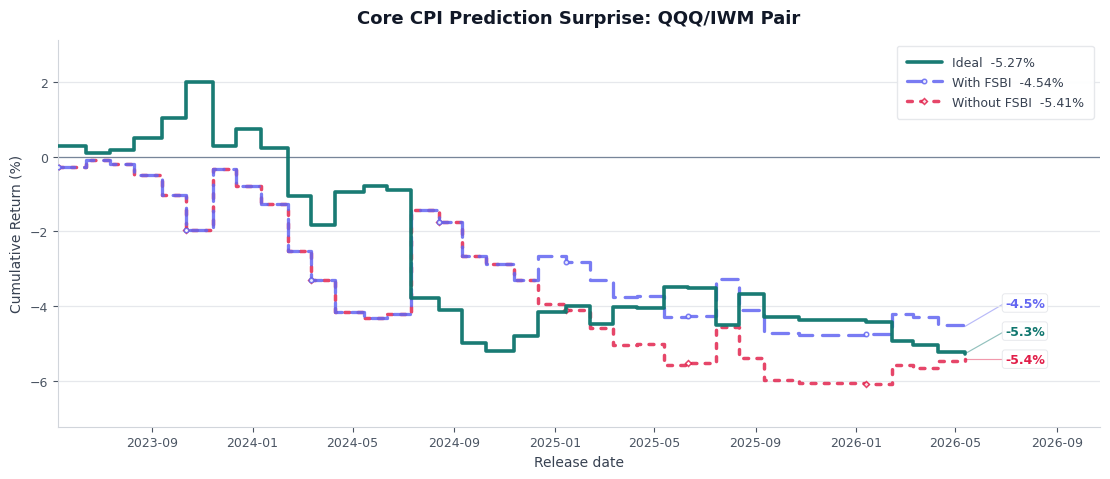

In [11]:
bt_qqq_iwm_pair = run_strategy_for_all_models({'name': 'QQQ/IWM pair', 'kind': 'pair', 'long_leg': 'QQQ', 'short_leg': 'IWM', 'title': 'Core CPI Prediction Surprise: QQQ/IWM Pair'}, prices)
show_strategy_comparison(bt_qqq_iwm_pair, 'Core CPI Prediction Surprise: QQQ/IWM Pair')

### 7. QQQ / VTV Pair

Economic reasoning:

This is a growth-versus-value trade. Higher inflation and higher rates can compress growth multiples, while cooler inflation can support long-duration growth equities.

Trading rule:

- Cooler signal: long QQQ and short VTV.
- Hotter signal: short QQQ and long VTV.

Code behavior:

The strategy evaluates whether Core CPI surprise information is better expressed as relative growth-versus-value exposure rather than outright equity exposure.

,Strategy,Model,Events,Trades,Total return (%),Avg trade (%),Win rate (%),Sharpe,Max DD (%)
0,QQQ/VTV pair,Ideal,35,35,1.24%,0.04%,60.00%,0.228214,-2.56%
1,QQQ/VTV pair,With FSBI,35,35,-3.47%,-0.10%,31.43%,-0.626395,-3.75%
2,QQQ/VTV pair,Without FSBI,35,35,-5.47%,-0.16%,31.43%,-1.032141,-5.74%


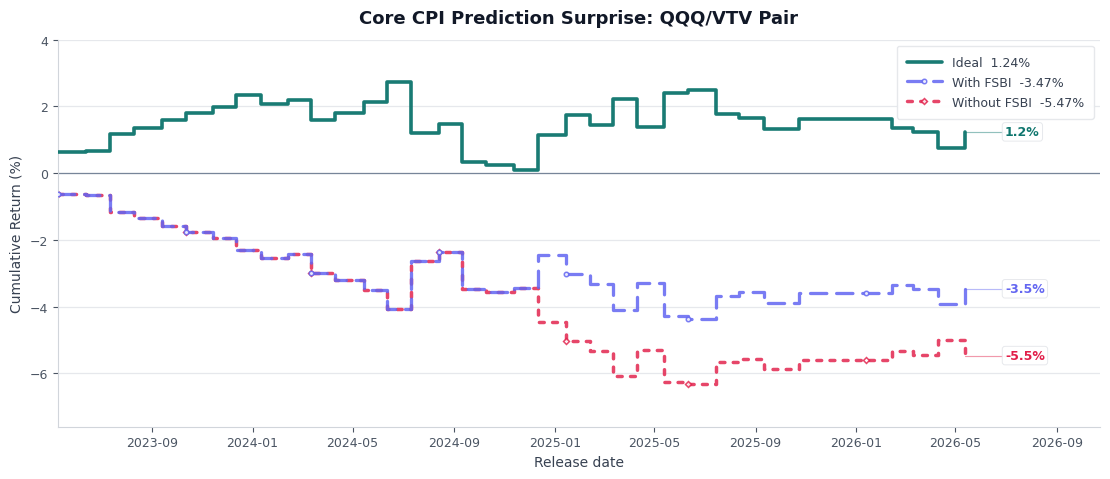

In [12]:
bt_qqq_vtv_pair = run_strategy_for_all_models({'name': 'QQQ/VTV pair', 'kind': 'pair', 'long_leg': 'QQQ', 'short_leg': 'VTV', 'title': 'Core CPI Prediction Surprise: QQQ/VTV Pair'}, prices)
show_strategy_comparison(bt_qqq_vtv_pair, 'Core CPI Prediction Surprise: QQQ/VTV Pair')

### 8. XLK / XLF Pair

Economic reasoning:

`XLK` represents technology exposure, while `XLF` represents financials. Inflation surprises can shift market expectations for rates and sector leadership. Technology tends to be more valuation-duration sensitive; financials can sometimes benefit from higher rate expectations.

Trading rule:

- Cooler signal: long XLK and short XLF.
- Hotter signal: short XLK and long XLF.

Code behavior:

The pair strategy tests sector rotation around inflation surprise events.

,Strategy,Model,Events,Trades,Total return (%),Avg trade (%),Win rate (%),Sharpe,Max DD (%)
0,XLK/XLF pair,Ideal,35,35,-1.23%,-0.03%,54.29%,-0.155259,-4.82%
1,XLK/XLF pair,With FSBI,35,35,-4.71%,-0.14%,37.14%,-0.649040,-4.94%
2,XLK/XLF pair,Without FSBI,35,35,-5.04%,-0.15%,37.14%,-0.699351,-4.81%


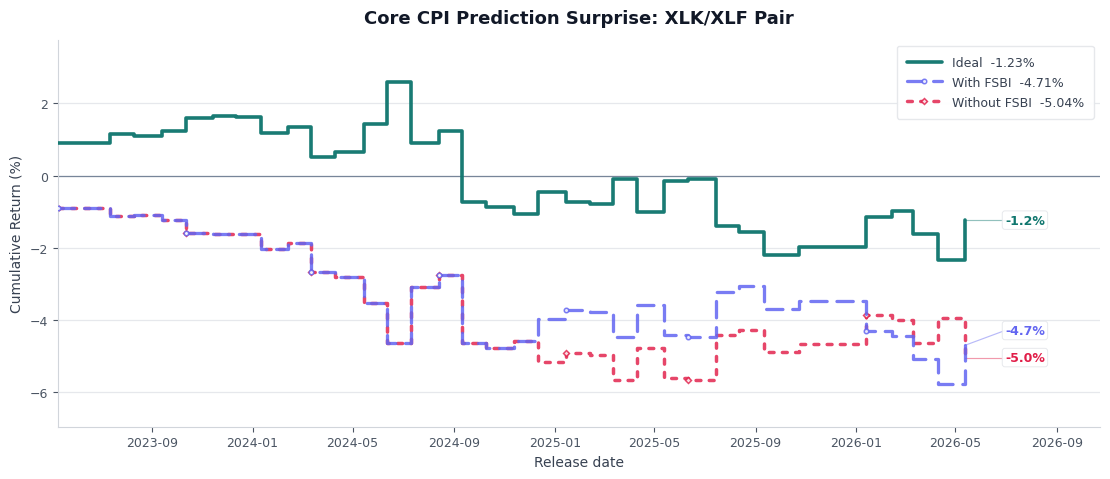

In [13]:
bt_xlk_xlf_pair = run_strategy_for_all_models({'name': 'XLK/XLF pair', 'kind': 'pair', 'long_leg': 'XLK', 'short_leg': 'XLF', 'title': 'Core CPI Prediction Surprise: XLK/XLF Pair'}, prices)
show_strategy_comparison(bt_xlk_xlf_pair, 'Core CPI Prediction Surprise: XLK/XLF Pair')

### 9. UUP Directional

Economic reasoning:

`UUP` tracks the U.S. dollar. Hotter inflation can increase expectations for tighter monetary policy and support the dollar, while cooler inflation can weaken that policy-support channel.

Trading rule:

- Positive inflation surprise: long UUP.
- Negative inflation surprise: short UUP.

Code behavior:

This strategy intentionally uses the opposite signal direction from TLT and QQQ because the economic response of the dollar to inflation surprises can be different from duration assets.

,Strategy,Model,Events,Trades,Total return (%),Avg trade (%),Win rate (%),Sharpe,Max DD (%)
0,UUP directional,Ideal,35,35,6.57%,0.18%,60.00%,1.028107,-1.08%
1,UUP directional,With FSBI,35,35,-2.95%,-0.08%,51.43%,-0.451443,-4.39%
2,UUP directional,Without FSBI,35,35,-3.23%,-0.09%,51.43%,-0.496758,-3.75%


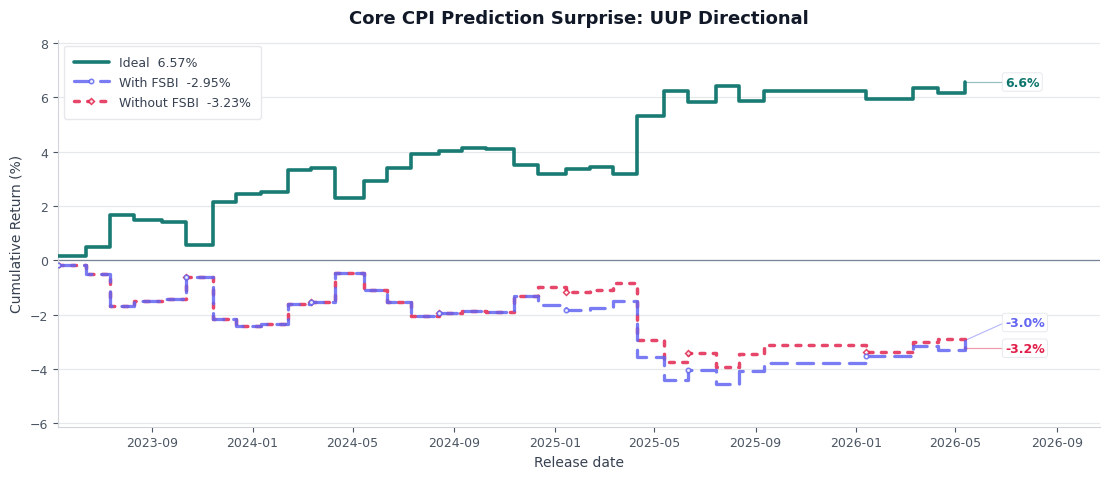

In [14]:
bt_uup_directional = run_strategy_for_all_models({'name': 'UUP directional', 'kind': 'directional', 'ticker': 'UUP', 'title': 'Core CPI Prediction Surprise: UUP Directional', 'signal_fn': dollar_signal}, prices)
show_strategy_comparison(bt_uup_directional, 'Core CPI Prediction Surprise: UUP Directional')

### 10. VIXY Pre-Release

Economic reasoning:

`VIXY` is a volatility-linked ETF. This strategy does not bet on the sign of inflation surprise. Instead, it tests whether large predicted surprises, positive or negative, are associated with larger event-day volatility.

Trading rule:

- If absolute surprise is at least the threshold, long VIXY.
- Otherwise, no position.

Code behavior:

The notebook uses `vixy_threshold` to decide whether the surprise is large enough to justify a volatility trade.

,Strategy,Model,Events,Trades,Total return (%),Avg trade (%),Win rate (%),Sharpe,Max DD (%)
0,VIXY pre-release,Ideal,35,16,-18.12%,-1.10%,25.00%,-0.652636,-21.48%
1,VIXY pre-release,With FSBI,35,31,-21.54%,-0.68%,35.48%,-0.501770,-24.60%
2,VIXY pre-release,Without FSBI,35,29,-24.45%,-0.85%,31.03%,-0.598393,-33.34%


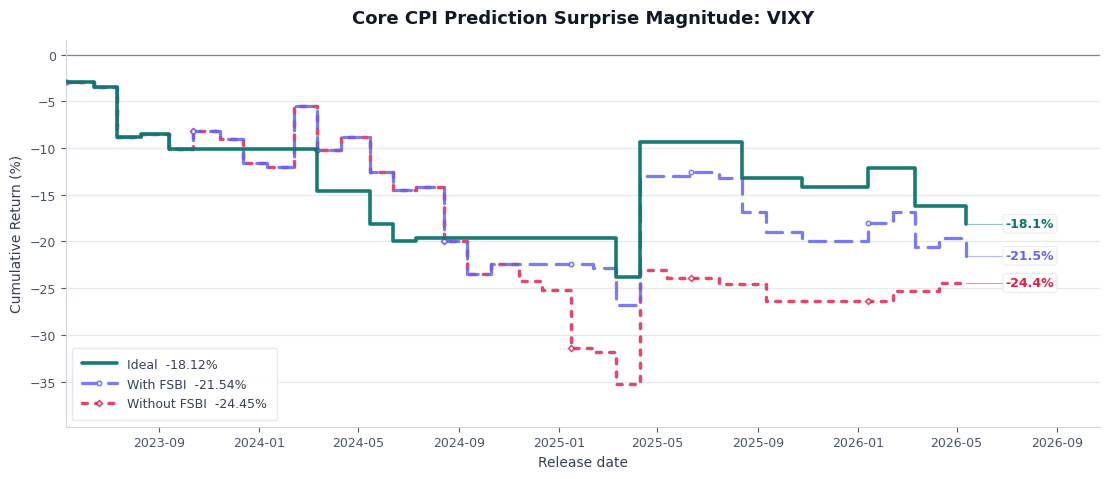

In [15]:
bt_vixy_pre_release = run_strategy_for_all_models({'name': 'VIXY pre-release', 'kind': 'directional', 'ticker': 'VIXY', 'title': 'Core CPI Prediction Surprise Magnitude: VIXY', 'signal_fn': vixy_signal}, prices)
show_strategy_comparison(bt_vixy_pre_release, 'Core CPI Prediction Surprise Magnitude: VIXY')

### 11. DBC / TLT Pair

Economic reasoning:

This pair compares broad commodities (`DBC`) with long-duration Treasuries (`TLT`). Hotter inflation can support commodities and hurt bonds, while cooler inflation can do the reverse.

Trading rule:

- Positive inflation surprise: long DBC and short TLT.
- Negative inflation surprise: short DBC and long TLT.

Code behavior:

This strategy tests a cross-asset inflation trade rather than a single-asset reaction.

,Strategy,Model,Events,Trades,Total return (%),Avg trade (%),Win rate (%),Sharpe,Max DD (%)
0,DBC/TLT pair,Ideal,35,35,2.24%,0.07%,60.00%,0.303561,-3.24%
1,DBC/TLT pair,With FSBI,35,35,6.66%,0.19%,54.29%,0.885200,-2.12%
2,DBC/TLT pair,Without FSBI,35,35,6.02%,0.17%,54.29%,0.799023,-2.12%


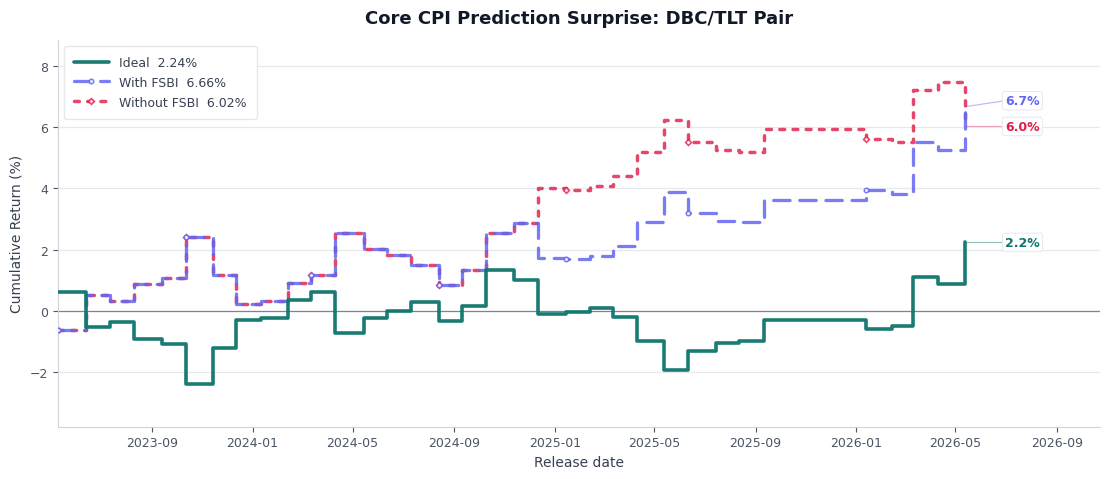

In [16]:
bt_dbc_tlt_pair = run_strategy_for_all_models({'name': 'DBC/TLT pair', 'kind': 'pair', 'long_leg': 'DBC', 'short_leg': 'TLT', 'title': 'Core CPI Prediction Surprise: DBC/TLT Pair', 'signal_fn': commodity_signal}, prices)
show_strategy_comparison(bt_dbc_tlt_pair, 'Core CPI Prediction Surprise: DBC/TLT Pair')

### 12. GLD Directional

Economic reasoning:

`GLD` represents gold exposure. Gold can react to inflation, real rates, the dollar, and safe-haven demand. Because these channels can conflict, this strategy is more exploratory than the Treasury duration strategies.

Trading rule:

The notebook applies the same sign convention used for duration-sensitive assets: hotter inflation is treated as negative for GLD and cooler inflation as positive.

Code behavior:

The strategy checks whether Core CPI surprise signals have a consistent event-day relationship with gold.

,Strategy,Model,Events,Trades,Total return (%),Avg trade (%),Win rate (%),Sharpe,Max DD (%)
0,GLD directional,Ideal,35,35,12.80%,0.35%,57.14%,1.402253,-1.74%
1,GLD directional,With FSBI,35,35,-4.64%,-0.13%,51.43%,-0.495275,-7.86%
2,GLD directional,Without FSBI,35,35,-7.78%,-0.23%,40.00%,-0.872457,-10.07%


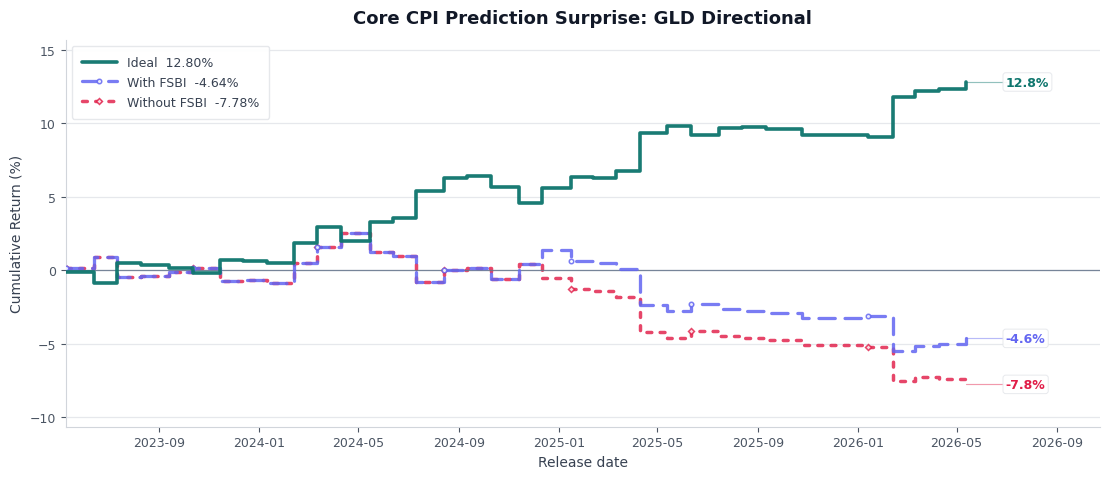

In [17]:
bt_gld_directional = run_strategy_for_all_models({'name': 'GLD directional', 'kind': 'directional', 'ticker': 'GLD', 'title': 'Core CPI Prediction Surprise: GLD Directional'}, prices)
show_strategy_comparison(bt_gld_directional, 'Core CPI Prediction Surprise: GLD Directional')

## 5. Overall Comparison

This section combines all strategy results into a single comparison table.

What to look for:

- Whether `With FSBI` improves performance versus `Without FSBI`.
- Whether the model-based signals resemble or diverge from the `Ideal` benchmark.
- Which asset classes are most responsive to the Core CPI surprise signal.

The `best_by_strategy` table selects the highest-return model version for each strategy.

In [18]:
all_backtests = pd.concat([bt_tlt_directional, bt_tlt_shy_spread, bt_tlt_ief_spread, bt_qqq_directional, bt_qqq_spy_pair, bt_qqq_iwm_pair, bt_qqq_vtv_pair, bt_xlk_xlf_pair, bt_uup_directional, bt_vixy_pre_release, bt_dbc_tlt_pair, bt_gld_directional], ignore_index=True)
overall_summary = summarize_backtest(all_backtests)
overall_summary = overall_summary.sort_values(['Strategy', 'Model']).reset_index(drop=True)
display_percent_table(overall_summary, ['Total return (%)', 'Avg trade (%)', 'Win rate (%)', 'Max DD (%)'])

best_by_strategy = overall_summary.sort_values('Total return (%)', ascending=False).groupby('Strategy', as_index=False).head(1)
display_percent_table(best_by_strategy.sort_values('Total return (%)', ascending=False), ['Total return (%)', 'Avg trade (%)', 'Win rate (%)', 'Max DD (%)'])

,Strategy,Model,Events,Trades,Total return (%),Avg trade (%),Win rate (%),Sharpe,Max DD (%)
0,DBC/TLT pair,Ideal,35,35,2.24%,0.07%,60.00%,0.303561,-3.24%
1,DBC/TLT pair,With FSBI,35,35,6.66%,0.19%,54.29%,0.885200,-2.12%
2,DBC/TLT pair,Without FSBI,35,35,6.02%,0.17%,54.29%,0.799023,-2.12%
3,GLD directional,Ideal,35,35,12.80%,0.35%,57.14%,1.402253,-1.74%
4,GLD directional,With FSBI,35,35,-4.64%,-0.13%,51.43%,-0.495275,-7.86%
5,GLD directional,Without FSBI,35,35,-7.78%,-0.23%,40.00%,-0.872457,-10.07%
6,QQQ directional,Ideal,35,35,7.61%,0.22%,60.00%,0.567410,-4.36%
7,QQQ directional,With FSBI,35,35,-4.02%,-0.11%,42.86%,-0.278566,-8.54%
8,QQQ directional,Without FSBI,35,35,-8.96%,-0.26%,37.14%,-0.677585,-11.76%
9,QQQ/IWM pair,Ideal,35,35,-5.27%,-0.15%,40.00%,-0.679668,-7.12%


,Strategy,Model,Events,Trades,Total return (%),Avg trade (%),Win rate (%),Sharpe,Max DD (%)
3,GLD directional,Ideal,35,35,12.80%,0.35%,57.14%,1.402253,-1.74%
6,QQQ directional,Ideal,35,35,7.61%,0.22%,60.00%,0.567410,-4.36%
20,TLT directional,Without FSBI,35,35,6.72%,0.19%,57.14%,0.560460,-3.66%
1,DBC/TLT pair,With FSBI,35,35,6.66%,0.19%,54.29%,0.885200,-2.12%
27,UUP directional,Ideal,35,35,6.57%,0.18%,60.00%,1.028107,-1.08%
26,TLT/SHY spread,Without FSBI,35,35,3.71%,0.11%,51.43%,0.685579,-1.58%
23,TLT/IEF spread,Without FSBI,35,35,3.36%,0.09%,51.43%,1.031067,-0.81%
12,QQQ/SPY pair,Ideal,35,35,1.56%,0.04%,65.71%,0.637235,-1.21%
15,QQQ/VTV pair,Ideal,35,35,1.24%,0.04%,60.00%,0.228214,-2.56%
33,XLK/XLF pair,Ideal,35,35,-1.23%,-0.03%,54.29%,-0.155259,-4.82%


## 6. Ranking and Evaluation Metrics

This section turns the backtest outputs into a report-style performance dashboard.

It ranks all `strategy x model` combinations by:

- **Sharpe ratio**: return efficiency relative to volatility.
- **Total return**: final cumulative return over the prediction sample.
- **Maximum drawdown magnitude**: downside risk; lower is better.

It also includes model-level averages and heatmaps to make it easier to see whether FSBI improves results consistently across strategies, or only in specific asset classes.

In [19]:
def prepare_model_ranking_table(overall_summary):
    ranking = overall_summary.copy()
    ranking['Strategy / Model'] = ranking['Strategy'] + ' | ' + ranking['Model']
    ranking['Drawdown magnitude (%)'] = ranking['Max DD (%)'].abs()
    ranking['Return / Drawdown'] = np.where(
        ranking['Drawdown magnitude (%)'] > 0,
        ranking['Total return (%)'] / ranking['Drawdown magnitude (%)'],
        np.nan,
    )
    return ranking


def show_ranked_model_table(df, sort_col, ascending=False, title=None, pct_cols=None, top_n=None):
    ranked = df.sort_values(sort_col, ascending=ascending).reset_index(drop=True)
    if top_n is not None:
        ranked = ranked.head(top_n).copy()
    ranked.insert(0, 'Rank', np.arange(1, len(ranked) + 1))
    if title:
        print(title)
    display_percent_table(
        ranked,
        pct_cols or ['Total return (%)', 'Avg trade (%)', 'Win rate (%)', 'Max DD (%)', 'Drawdown magnitude (%)'],
    )
    return ranked


model_ranking = prepare_model_ranking_table(overall_summary)

sharpe_model_rank = show_ranked_model_table(
    model_ranking,
    'Sharpe',
    ascending=False,
    title='Top strategy-model combinations by Sharpe ratio',
    top_n=15,
)

return_model_rank = show_ranked_model_table(
    model_ranking,
    'Total return (%)',
    ascending=False,
    title='Top strategy-model combinations by total return',
    top_n=15,
)

drawdown_model_rank = show_ranked_model_table(
    model_ranking,
    'Drawdown magnitude (%)',
    ascending=True,
    title='Top strategy-model combinations by maximum drawdown: smaller is better',
    top_n=15,
)

Top strategy-model combinations by Sharpe ratio


,Rank,Strategy,Model,Events,Trades,Total return (%),Avg trade (%),Win rate (%),Sharpe,Max DD (%),Strategy / Model,Drawdown magnitude (%),Return / Drawdown
0,1,GLD directional,Ideal,35,35,12.80%,0.35%,57.14%,1.402253,-1.74%,GLD directional | Ideal,1.74%,7.379714
1,2,TLT/IEF spread,Without FSBI,35,35,3.36%,0.09%,51.43%,1.031067,-0.81%,TLT/IEF spread | Without FSBI,0.81%,4.126183
2,3,UUP directional,Ideal,35,35,6.57%,0.18%,60.00%,1.028107,-1.08%,UUP directional | Ideal,1.08%,6.056498
3,4,TLT/IEF spread,With FSBI,35,35,3.06%,0.09%,51.43%,0.932753,-0.84%,TLT/IEF spread | With FSBI,0.84%,3.640564
4,5,DBC/TLT pair,With FSBI,35,35,6.66%,0.19%,54.29%,0.885200,-2.12%,DBC/TLT pair | With FSBI,2.12%,3.145140
5,6,DBC/TLT pair,Without FSBI,35,35,6.02%,0.17%,54.29%,0.799023,-2.12%,DBC/TLT pair | Without FSBI,2.12%,2.842625
6,7,TLT/SHY spread,Without FSBI,35,35,3.71%,0.11%,51.43%,0.685579,-1.58%,TLT/SHY spread | Without FSBI,1.58%,2.349019
7,8,QQQ/SPY pair,Ideal,35,35,1.56%,0.04%,65.71%,0.637235,-1.21%,QQQ/SPY pair | Ideal,1.21%,1.286390
8,9,TLT/SHY spread,With FSBI,35,35,3.43%,0.10%,51.43%,0.633881,-2.00%,TLT/SHY spread | With FSBI,2.00%,1.712754
9,10,QQQ directional,Ideal,35,35,7.61%,0.22%,60.00%,0.567410,-4.36%,QQQ directional | Ideal,4.36%,1.743735


Top strategy-model combinations by total return


,Rank,Strategy,Model,Events,Trades,Total return (%),Avg trade (%),Win rate (%),Sharpe,Max DD (%),Strategy / Model,Drawdown magnitude (%),Return / Drawdown
0,1,GLD directional,Ideal,35,35,12.80%,0.35%,57.14%,1.402253,-1.74%,GLD directional | Ideal,1.74%,7.379714
1,2,QQQ directional,Ideal,35,35,7.61%,0.22%,60.00%,0.567410,-4.36%,QQQ directional | Ideal,4.36%,1.743735
2,3,TLT directional,Without FSBI,35,35,6.72%,0.19%,57.14%,0.560460,-3.66%,TLT directional | Without FSBI,3.66%,1.833161
3,4,DBC/TLT pair,With FSBI,35,35,6.66%,0.19%,54.29%,0.885200,-2.12%,DBC/TLT pair | With FSBI,2.12%,3.145140
4,5,UUP directional,Ideal,35,35,6.57%,0.18%,60.00%,1.028107,-1.08%,UUP directional | Ideal,1.08%,6.056498
5,6,TLT directional,With FSBI,35,35,6.27%,0.18%,57.14%,0.525044,-4.88%,TLT directional | With FSBI,4.88%,1.284689
6,7,DBC/TLT pair,Without FSBI,35,35,6.02%,0.17%,54.29%,0.799023,-2.12%,DBC/TLT pair | Without FSBI,2.12%,2.842625
7,8,TLT directional,Ideal,35,35,3.80%,0.11%,62.86%,0.327635,-4.33%,TLT directional | Ideal,4.33%,0.876930
8,9,TLT/SHY spread,Without FSBI,35,35,3.71%,0.11%,51.43%,0.685579,-1.58%,TLT/SHY spread | Without FSBI,1.58%,2.349019
9,10,TLT/SHY spread,With FSBI,35,35,3.43%,0.10%,51.43%,0.633881,-2.00%,TLT/SHY spread | With FSBI,2.00%,1.712754


Top strategy-model combinations by maximum drawdown: smaller is better


,Rank,Strategy,Model,Events,Trades,Total return (%),Avg trade (%),Win rate (%),Sharpe,Max DD (%),Strategy / Model,Drawdown magnitude (%),Return / Drawdown
0,1,TLT/IEF spread,Without FSBI,35,35,3.36%,0.09%,51.43%,1.031067,-0.81%,TLT/IEF spread | Without FSBI,0.81%,4.126183
1,2,TLT/IEF spread,With FSBI,35,35,3.06%,0.09%,51.43%,0.932753,-0.84%,TLT/IEF spread | With FSBI,0.84%,3.640564
2,3,UUP directional,Ideal,35,35,6.57%,0.18%,60.00%,1.028107,-1.08%,UUP directional | Ideal,1.08%,6.056498
3,4,QQQ/SPY pair,Ideal,35,35,1.56%,0.04%,65.71%,0.637235,-1.21%,QQQ/SPY pair | Ideal,1.21%,1.286390
4,5,TLT/SHY spread,Without FSBI,35,35,3.71%,0.11%,51.43%,0.685579,-1.58%,TLT/SHY spread | Without FSBI,1.58%,2.349019
5,6,GLD directional,Ideal,35,35,12.80%,0.35%,57.14%,1.402253,-1.74%,GLD directional | Ideal,1.74%,7.379714
6,7,TLT/IEF spread,Ideal,35,35,-0.42%,-0.01%,62.86%,-0.118273,-1.91%,TLT/IEF spread | Ideal,1.91%,-0.217426
7,8,TLT/SHY spread,With FSBI,35,35,3.43%,0.10%,51.43%,0.633881,-2.00%,TLT/SHY spread | With FSBI,2.00%,1.712754
8,9,QQQ/SPY pair,With FSBI,35,35,-1.89%,-0.05%,25.71%,-0.782772,-2.02%,QQQ/SPY pair | With FSBI,2.02%,-0.934989
9,10,DBC/TLT pair,With FSBI,35,35,6.66%,0.19%,54.29%,0.885200,-2.12%,DBC/TLT pair | With FSBI,2.12%,3.145140


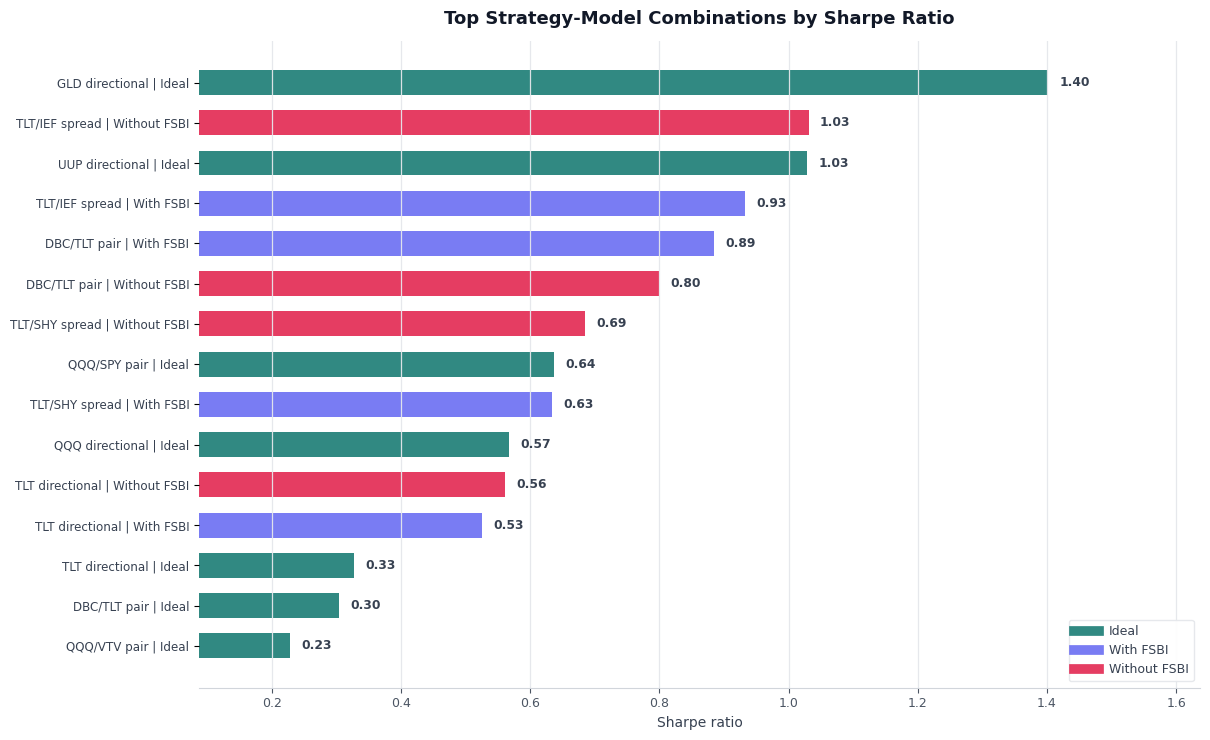

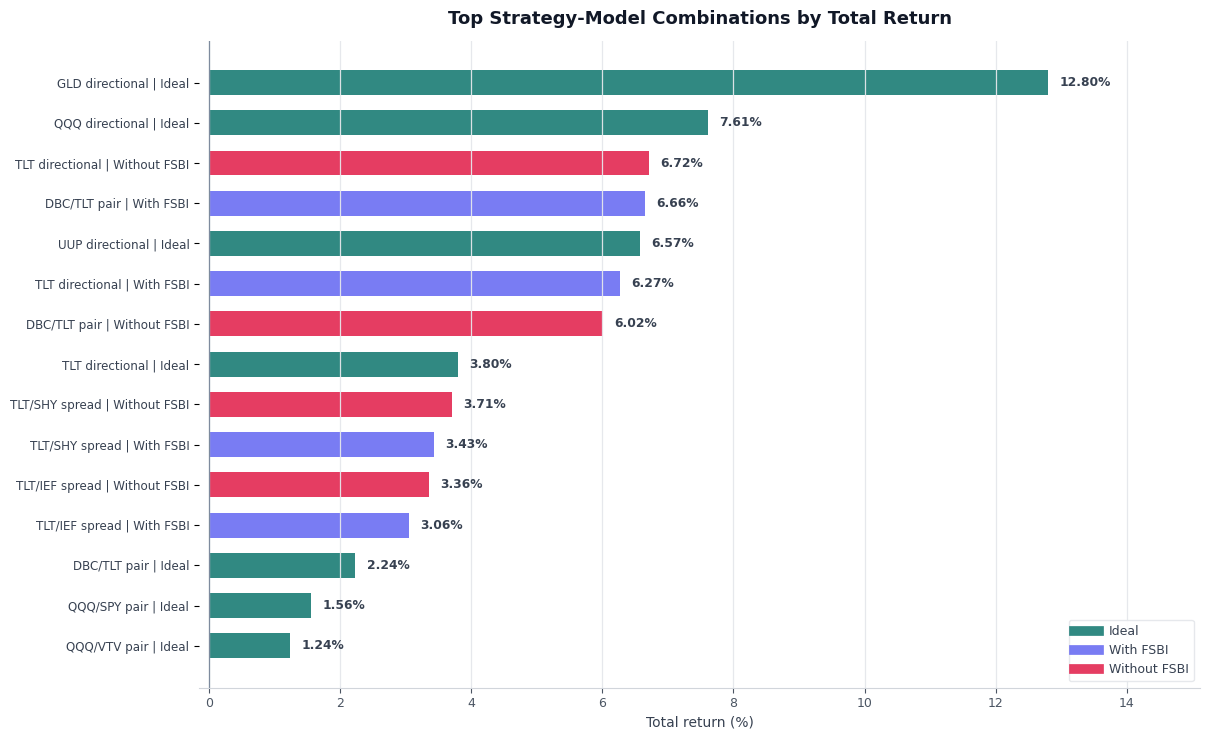

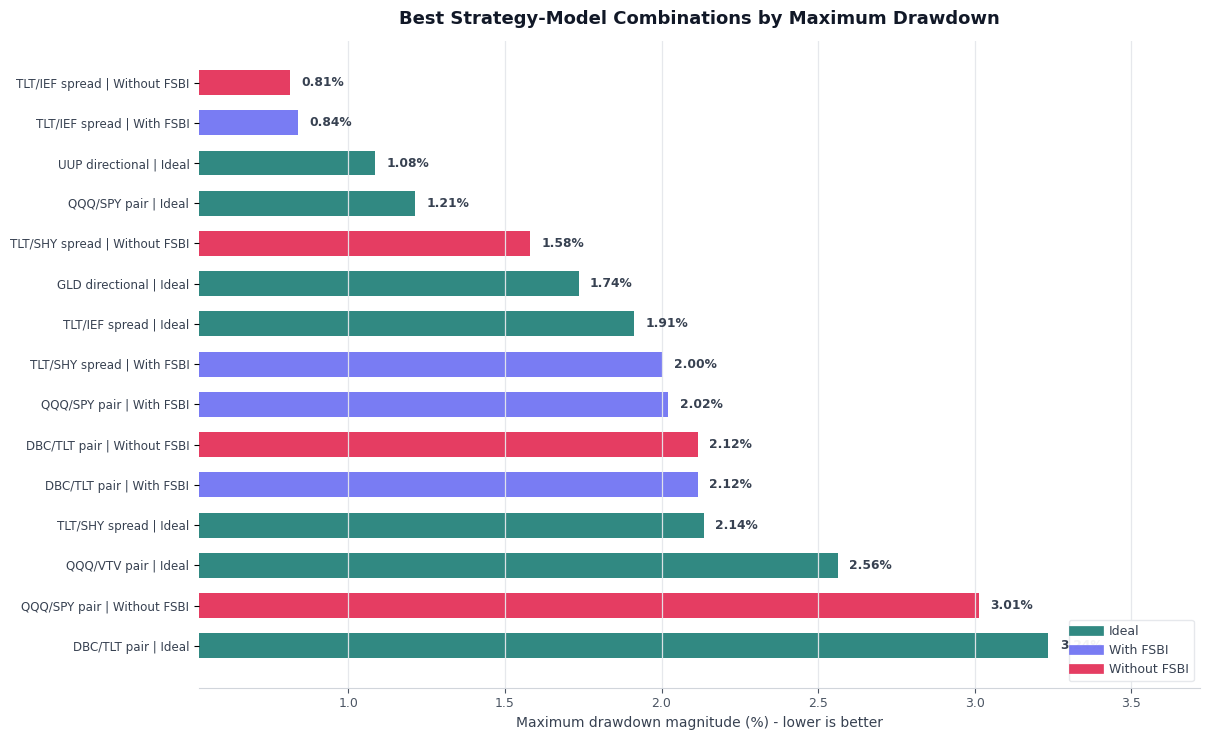

<Axes: title={'center': 'Best Strategy-Model Combinations by Maximum Drawdown'}, xlabel='Maximum drawdown magnitude (%) - lower is better'>

In [20]:
MODEL_COLORS = {
    'Ideal': '#0f766e',
    'With FSBI': '#6366f1',
    'Without FSBI': '#e11d48',
}


def plot_ranked_model_bar(df, value_col, title, ascending=True, xlabel=None, value_fmt='{:.2f}', top_n=15, zero_line=True):
    plot_df = df.sort_values(value_col, ascending=ascending).head(top_n).copy()
    # Horizontal bars render the last row at the top, so reverse the display order
    # after selecting the best rows. This keeps the best item visually on top
    # for both high-is-good metrics and low-is-good metrics like drawdown.
    plot_df = plot_df.sort_values(value_col, ascending=not ascending)
    fig_height = max(5.2, 0.42 * len(plot_df) + 1.2)
    fig, ax = plt.subplots(figsize=(12.2, fig_height))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    labels = plot_df['Strategy / Model']
    values = plot_df[value_col].to_numpy()
    colors = plot_df['Model'].map(MODEL_COLORS).fillna('#64748b')
    y = np.arange(len(plot_df))

    ax.barh(y, values, color=colors, alpha=0.86, height=0.62)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8.6, color='#374151')
    ax.set_title(title, fontsize=13, fontweight='semibold', color='#111827', pad=12)
    ax.set_xlabel(xlabel or value_col, color='#374151')
    ax.tick_params(axis='x', colors='#4b5563', labelsize=9)
    ax.grid(True, axis='x', color='#e5e7eb', linewidth=0.9, alpha=0.95)
    ax.grid(False, axis='y')

    if zero_line:
        ax.axvline(0, color='#64748b', linewidth=0.9, alpha=0.8)

    x_min, x_max = np.nanmin(values), np.nanmax(values)
    x_range = max(x_max - x_min, 1.0)
    ax.set_xlim(x_min - x_range * 0.12, x_max + x_range * 0.20)

    for yi, value in zip(y, values):
        ha = 'left' if value >= 0 else 'right'
        offset = x_range * 0.015 if value >= 0 else -x_range * 0.015
        ax.text(value + offset, yi, value_fmt.format(value), va='center', ha=ha, fontsize=8.8, color='#374151', fontweight='semibold')

    legend_handles = [plt.Line2D([0], [0], color=color, lw=7, alpha=0.86, label=model) for model, color in MODEL_COLORS.items()]
    legend = ax.legend(handles=legend_handles, loc='lower right', frameon=True, fancybox=True, framealpha=0.94, facecolor='white', edgecolor='#e5e7eb', fontsize=9)
    for text in legend.get_texts():
        text.set_color('#374151')

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#d1d5db')
    plt.tight_layout()
    plt.show()
    return ax


plot_ranked_model_bar(
    model_ranking,
    'Sharpe',
    'Top Strategy-Model Combinations by Sharpe Ratio',
    ascending=False,
    xlabel='Sharpe ratio',
    value_fmt='{:.2f}',
    top_n=15,
)

plot_ranked_model_bar(
    model_ranking,
    'Total return (%)',
    'Top Strategy-Model Combinations by Total Return',
    ascending=False,
    xlabel='Total return (%)',
    value_fmt='{:.2f}%',
    top_n=15,
)

plot_ranked_model_bar(
    model_ranking,
    'Drawdown magnitude (%)',
    'Best Strategy-Model Combinations by Maximum Drawdown',
    ascending=True,
    xlabel='Maximum drawdown magnitude (%) - lower is better',
    value_fmt='{:.2f}%',
    top_n=15,
    zero_line=False,
)

,Model,Avg_total_return_pct,Median_total_return_pct,Avg_sharpe,Avg_drawdown_magnitude_pct,Positive_return_rate_pct
0,Ideal,0.99%,1.40%,0.257752,4.67%,66.67%
1,With FSBI,-2.36%,-3.21%,-0.115583,5.89%,33.33%
2,Without FSBI,-3.65%,-4.17%,-0.288783,7.22%,33.33%


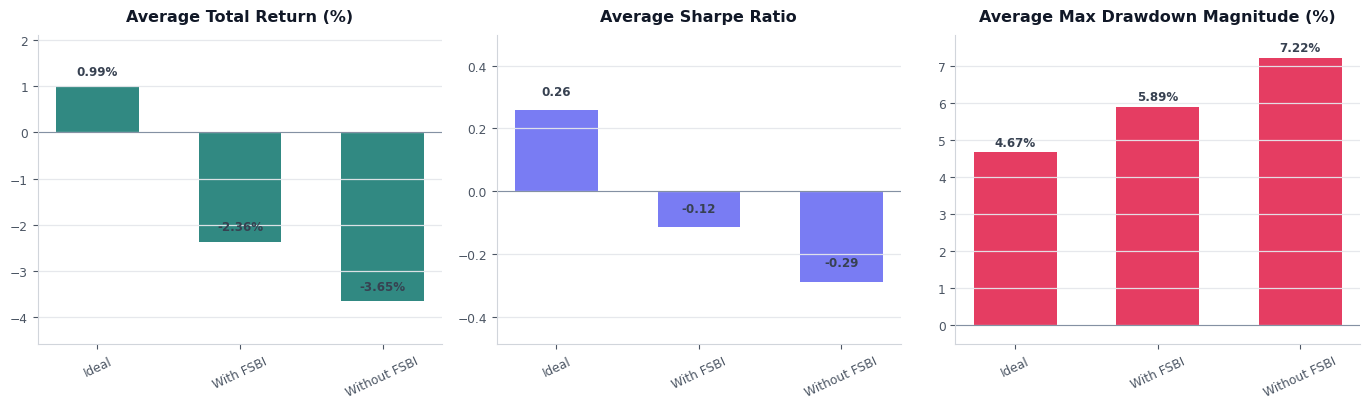

array([<Axes: title={'center': 'Average Total Return (%)'}>,
       <Axes: title={'center': 'Average Sharpe Ratio'}>,
       <Axes: title={'center': 'Average Max Drawdown Magnitude (%)'}>],
      dtype=object)

In [21]:
def summarize_by_model(overall_summary):
    out = overall_summary.groupby('Model').agg(
        Avg_total_return_pct=('Total return (%)', 'mean'),
        Median_total_return_pct=('Total return (%)', 'median'),
        Avg_sharpe=('Sharpe', 'mean'),
        Avg_drawdown_magnitude_pct=('Max DD (%)', lambda s: s.abs().mean()),
        Positive_return_rate_pct=('Total return (%)', lambda s: (s > 0).mean() * 100),
    ).reset_index()
    out['Model'] = pd.Categorical(out['Model'], categories=list(MODEL_SPECS.keys()), ordered=True)
    return out.sort_values('Model').reset_index(drop=True)


model_summary = summarize_by_model(overall_summary)
display_percent_table(
    model_summary,
    ['Avg_total_return_pct', 'Median_total_return_pct', 'Avg_drawdown_magnitude_pct', 'Positive_return_rate_pct'],
)


def plot_model_summary(model_summary):
    metrics = [
        ('Avg_total_return_pct', 'Average Total Return (%)', '#0f766e'),
        ('Avg_sharpe', 'Average Sharpe Ratio', '#6366f1'),
        ('Avg_drawdown_magnitude_pct', 'Average Max Drawdown Magnitude (%)', '#e11d48'),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.2))
    fig.patch.set_facecolor('white')

    for ax, (col, title, color) in zip(axes, metrics):
        ax.set_facecolor('white')
        values = model_summary[col].to_numpy()
        labels = model_summary['Model'].astype(str).to_list()
        bars = ax.bar(labels, values, color=color, alpha=0.86, width=0.58)
        ax.set_title(title, fontsize=11.5, fontweight='semibold', color='#111827', pad=10)
        ax.tick_params(axis='x', labelrotation=25, colors='#4b5563', labelsize=8.8)
        ax.tick_params(axis='y', colors='#4b5563', labelsize=8.8)
        ax.grid(True, axis='y', color='#e5e7eb', linewidth=0.9, alpha=0.95)
        ax.grid(False, axis='x')
        ax.axhline(0, color='#64748b', linewidth=0.8, alpha=0.75)

        y_min, y_max = np.nanmin(values), np.nanmax(values)
        y_range = max(y_max - y_min, 1.0)
        ax.set_ylim(min(0, y_min) - y_range * 0.20, y_max + y_range * 0.24)
        for bar, value in zip(bars, values):
            fmt = f'{value:.2f}' if col == 'Avg_sharpe' else f'{value:.2f}%'
            ax.text(bar.get_x() + bar.get_width()/2, value + y_range * 0.04, fmt, ha='center', va='bottom', fontsize=8.6, color='#374151', fontweight='semibold')
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        ax.spines['left'].set_color('#d1d5db')
        ax.spines['bottom'].set_color('#d1d5db')

    plt.tight_layout()
    plt.show()
    return axes


plot_model_summary(model_summary)

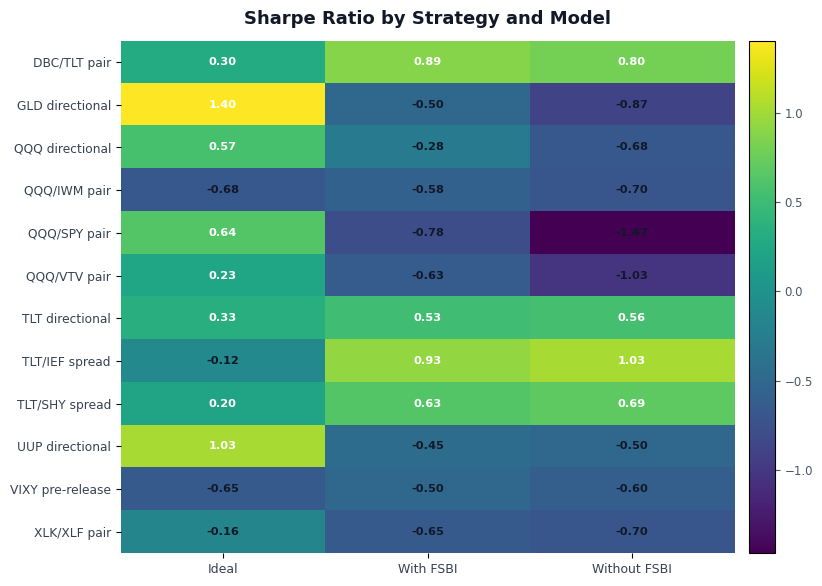

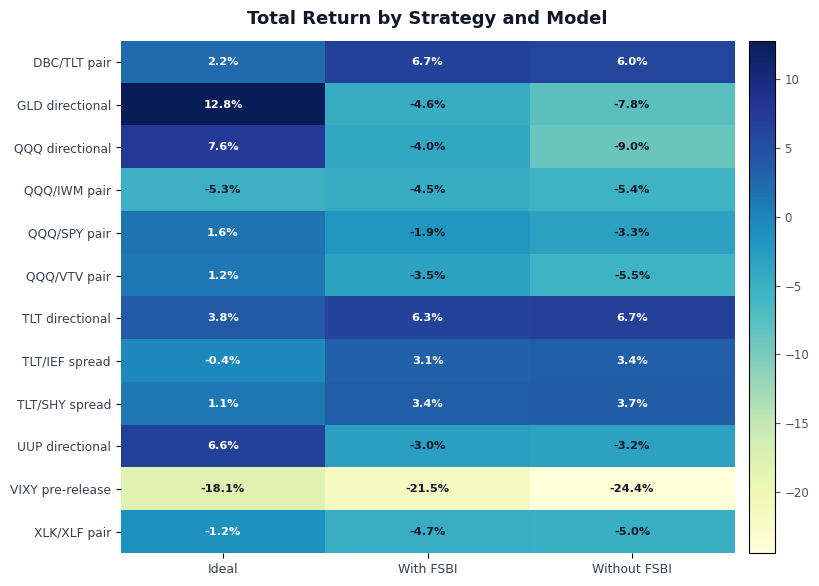

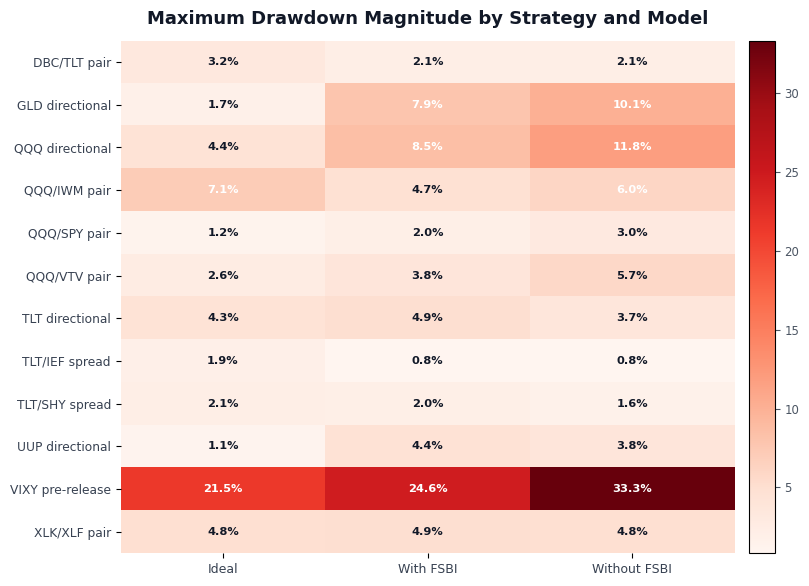

<Axes: title={'center': 'Maximum Drawdown Magnitude by Strategy and Model'}>

In [22]:
def plot_metric_heatmap(summary, metric, title, cmap='viridis', fmt='{:.2f}'):
    pivot = summary.pivot(index='Strategy', columns='Model', values=metric)
    pivot = pivot[list(MODEL_SPECS.keys())]

    fig, ax = plt.subplots(figsize=(8.8, max(5.2, 0.38 * len(pivot) + 1.4)))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    data = pivot.to_numpy(dtype=float)
    im = ax.imshow(data, aspect='auto', cmap=cmap)

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=9, color='#374151')
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8.8, color='#374151')
    ax.set_title(title, fontsize=13, fontweight='semibold', color='#111827', pad=12)

    finite = data[np.isfinite(data)]
    threshold = np.nanmean(finite) if len(finite) else 0
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            value = data[i, j]
            text_color = 'white' if value > threshold else '#111827'
            suffix = '%' if '%' in metric else ''
            ax.text(j, i, fmt.format(value) + suffix, ha='center', va='center', fontsize=8.2, color=text_color, fontweight='semibold')

    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    cbar.ax.tick_params(colors='#4b5563', labelsize=8.5)

    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()
    return ax


plot_metric_heatmap(overall_summary, 'Sharpe', 'Sharpe Ratio by Strategy and Model', cmap='viridis', fmt='{:.2f}')
plot_metric_heatmap(overall_summary, 'Total return (%)', 'Total Return by Strategy and Model', cmap='YlGnBu', fmt='{:.1f}')
plot_metric_heatmap(model_ranking, 'Drawdown magnitude (%)', 'Maximum Drawdown Magnitude by Strategy and Model', cmap='Reds', fmt='{:.1f}')

In [23]:
report_view = model_ranking[[
    'Strategy', 'Model', 'Total return (%)', 'Sharpe', 'Max DD (%)',
    'Drawdown magnitude (%)', 'Return / Drawdown', 'Win rate (%)', 'Trades'
]].copy()
report_view = report_view.sort_values(['Sharpe', 'Total return (%)'], ascending=False).reset_index(drop=True)
report_view.insert(0, 'Overall rank by Sharpe', np.arange(1, len(report_view) + 1))

display_percent_table(
    report_view,
    ['Total return (%)', 'Max DD (%)', 'Drawdown magnitude (%)', 'Win rate (%)'],
)

,Overall rank by Sharpe,Strategy,Model,Total return (%),Sharpe,Max DD (%),Drawdown magnitude (%),Return / Drawdown,Win rate (%),Trades
0,1,GLD directional,Ideal,12.80%,1.402253,-1.74%,1.74%,7.379714,57.14%,35
1,2,TLT/IEF spread,Without FSBI,3.36%,1.031067,-0.81%,0.81%,4.126183,51.43%,35
2,3,UUP directional,Ideal,6.57%,1.028107,-1.08%,1.08%,6.056498,60.00%,35
3,4,TLT/IEF spread,With FSBI,3.06%,0.932753,-0.84%,0.84%,3.640564,51.43%,35
4,5,DBC/TLT pair,With FSBI,6.66%,0.885200,-2.12%,2.12%,3.145140,54.29%,35
5,6,DBC/TLT pair,Without FSBI,6.02%,0.799023,-2.12%,2.12%,2.842625,54.29%,35
6,7,TLT/SHY spread,Without FSBI,3.71%,0.685579,-1.58%,1.58%,2.349019,51.43%,35
7,8,QQQ/SPY pair,Ideal,1.56%,0.637235,-1.21%,1.21%,1.286390,65.71%,35
8,9,TLT/SHY spread,With FSBI,3.43%,0.633881,-2.00%,2.00%,1.712754,51.43%,35
9,10,QQQ directional,Ideal,7.61%,0.567410,-4.36%,4.36%,1.743735,60.00%,35


## 7. Date Alignment Audit

This section checks that the backtest dates are aligned correctly.

The key test is whether `exit_date` matches the prediction file's `Actual Release Date`. If a release date is not an ETF trading day, the event is excluded and reported here.

This audit is important because event-driven macro backtests are highly sensitive to date alignment. A one-day mismatch can materially change the result.

In [24]:
def audit_alignment(all_backtests, signal_table):
    release_set = set(signal_table['release_date'].dt.normalize())
    rows = []
    for (strategy, model), g in all_backtests.groupby(['strategy', 'model'], sort=False):
        traded_release_set = set(pd.to_datetime(g['release_date']).dt.normalize())
        not_traded = sorted(release_set - traded_release_set)
        exit_mismatch = (pd.to_datetime(g['exit_date']).dt.normalize() != pd.to_datetime(g['release_date']).dt.normalize()).sum()
        rows.append({
            'Strategy': strategy,
            'Model': model,
            'Rows': len(g),
            'Unique release dates': g['release_date'].nunique(),
            'Exit date mismatches': int(exit_mismatch),
            'Not traded events': len(not_traded),
            'Not traded examples': ';'.join(d.strftime('%Y-%m-%d') for d in not_traded[:10]),
        })
    return pd.DataFrame(rows)

alignment_audit = audit_alignment(all_backtests, signal_table)
display(alignment_audit)

,Strategy,Model,Rows,Unique release dates,Exit date mismatches,Not traded events,Not traded examples
0,TLT directional,Ideal,35,35,0,0,
1,TLT directional,With FSBI,35,35,0,0,
2,TLT directional,Without FSBI,35,35,0,0,
3,TLT/SHY spread,Ideal,35,35,0,0,
4,TLT/SHY spread,With FSBI,35,35,0,0,
5,TLT/SHY spread,Without FSBI,35,35,0,0,
6,TLT/IEF spread,Ideal,35,35,0,0,
7,TLT/IEF spread,With FSBI,35,35,0,0,
8,TLT/IEF spread,Without FSBI,35,35,0,0,
9,QQQ directional,Ideal,35,35,0,0,
